<a href="https://colab.research.google.com/github/f-Ayuk/Intro_to_ML-Summative/blob/main/Intro_to_ML_Summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installations, Imports, Setup, Data Handling

Installing Packages

In [ ]:
!pip install -q xgboost shap seaborn scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 1.3 MB/s eta 0:00:00


Imports

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler,OneHotEncoder,LabelEncoder)
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    Concatenate
)

import shap

Loading the dataset

In [ ]:
df = pd.read_csv('/content/fertilizer_recommendation.csv')

df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [ ]:
df.shape
df.info()
df.describe()
print(df.shape)
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  object 
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  object 
 12  Crop_Growth_Stage            10000 non-null  object 
 13  Season           

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000,10000,10000,10000.000000,10000.000000,10000
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,4,3,4,7,5,NaN,NaN,7
top,Sandy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wheat,Harvest,Kharif,Sprinkler,Cotton,West,NaN,NaN,Urea
freq,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1467,2547,3363,2531,1492,2026,NaN,NaN,3101
mean,NaN,6.485728,35.411531,0.844731,1.543156,88.995000,48.965100,64.147000,25.058906,60.093727,1588.085798,NaN,NaN,NaN,NaN,NaN,NaN,176.165508,4.531666,NaN
std,NaN,1.152964,14.413002,0.372406,0.839514,40.336674,23.195588,31.867211,8.601550,17.386120,810.992404,NaN,NaN,NaN,NaN,NaN,NaN,72.235790,2.013522,NaN
min,NaN,4.500000,10.000000,0.200000,0.100000,20.000000,10.000000,10.000000,10.000000,30.010000,200.080000,NaN,NaN,NaN,NaN,NaN,NaN,50.010000,1.000000,NaN
25%,NaN,5.490000,23.030000,0.520000,0.820000,54.000000,29.000000,37.000000,17.580000,44.925000,874.780000,NaN,NaN,NaN,NaN,NaN,NaN,113.175000,2.780000,NaN
50%,NaN,6.460000,35.645000,0.850000,1.530000,89.000000,49.000000,64.000000,25.085000,60.345000,1594.295000,NaN,NaN,NaN,NaN,NaN,NaN,176.835000,4.550000,NaN
75%,NaN,7.490000,47.662500,1.160000,2.270000,124.000000,69.000000,92.000000,32.502500,75.420000,2283.782500,NaN,NaN,NaN,NaN,NaN,NaN,239.232500,6.260000,NaN


Missing Values

In [ ]:
df.isnull().sum()

,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Nitrogen_Level,0
Phosphorus_Level,0
Potassium_Level,0
Temperature,0
Humidity,0


Target Distribution

<Axes: xlabel='Recommended_Fertilizer', ylabel='count'>

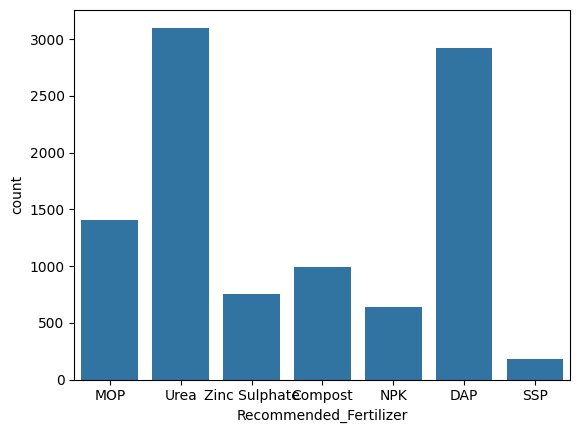

In [ ]:
sns.countplot(x='Recommended_Fertilizer', data=df)

Correlation Heatmap

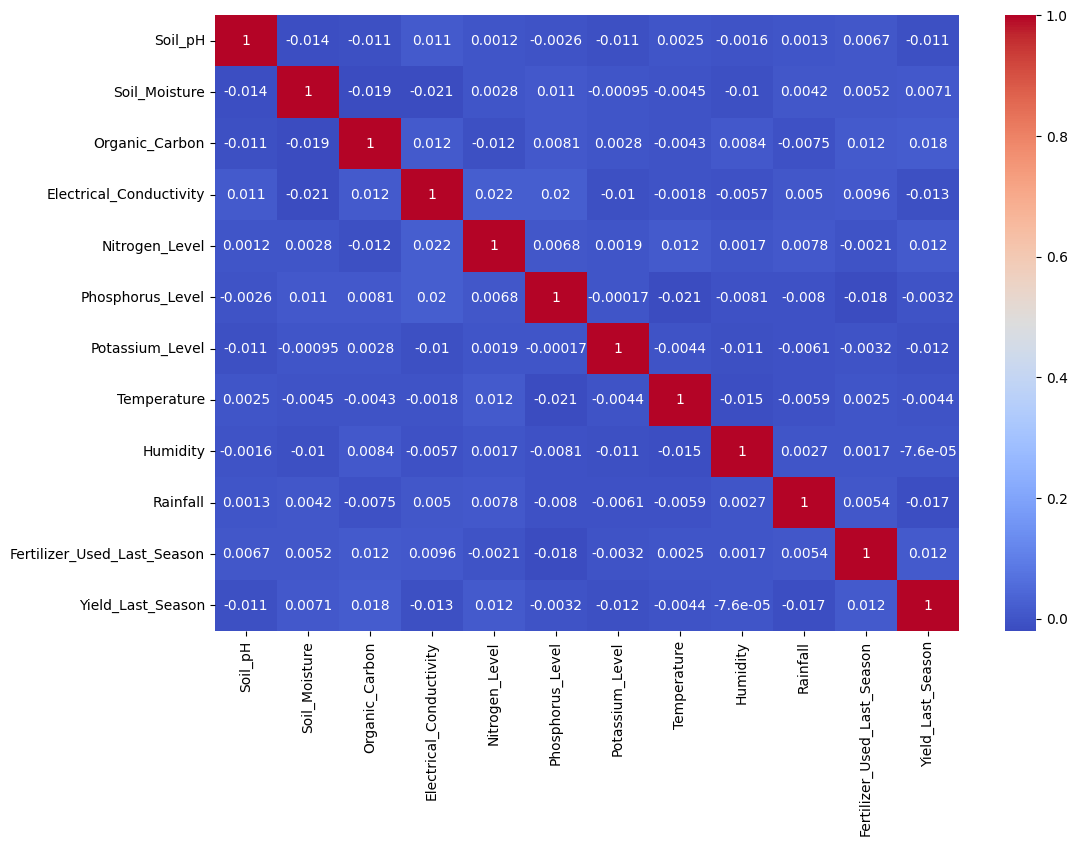

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Crop Distribution

<Axes: xlabel='count', ylabel='Crop_Type'>

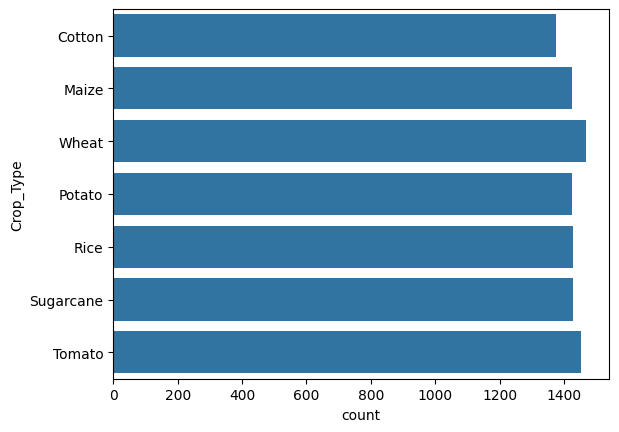

In [ ]:
sns.countplot(y='Crop_Type', data=df)

<Axes: xlabel='count', ylabel='Soil_Type'>

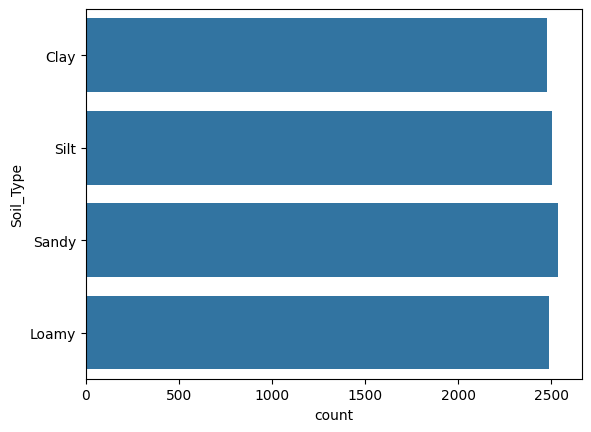

In [ ]:
sns.countplot(y='Soil_Type', data=df)

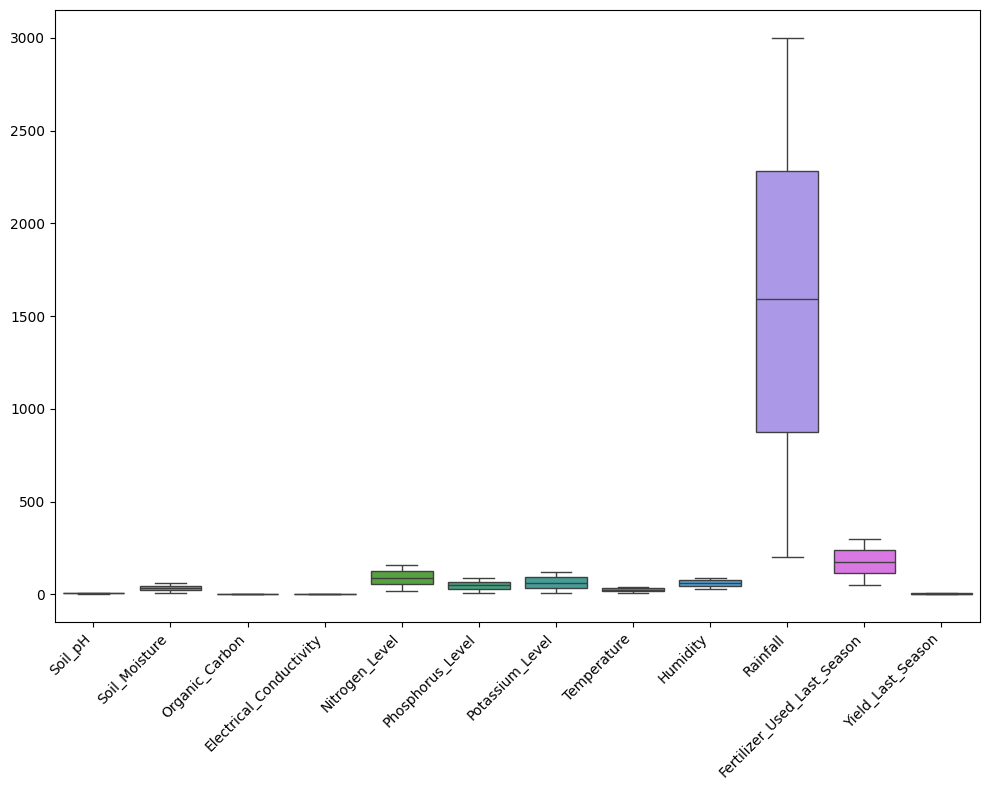

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

plt.figure(figsize=(10,8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

4. Feature Engineering

In [ ]:
# Feature engineering
df["NPK_Total"] = df["Nitrogen_Level"] + df["Phosphorus_Level"] + df["Potassium_Level"]
df["NPK_Balance"] = df["Nitrogen_Level"] / (df["Potassium_Level"] + 1)
df["Climate_Index"] = df["Temperature"] * df["Humidity"]
df["Soil_Fertility_Index"] = df["Organic_Carbon"] * df["Soil_pH"] / (df["Electrical_Conductivity"] + 1)

5. Data Split

In [ ]:
X = df.drop("Recommended_Fertilizer", axis=1)
y = LabelEncoder().fit_transform(df["Recommended_Fertilizer"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42, stratify=y_train)

6. Preprocessing Pipeline

In [ ]:
num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

preprocessor.fit(X_train)
X_train_dl = preprocessor.transform(X_train)
X_val_dl = preprocessor.transform(X_val)
X_test_dl = preprocessor.transform(X_test)

## Storing the Result

In [ ]:
ml_results = []
dl_results = []

In [ ]:
ml_df = pd.DataFrame(
    ml_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
)

ml_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC


In [ ]:
dl_df = pd.DataFrame(
    dl_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "Train Loss", "Val Loss"]
).sort_values("F1", ascending=False)

## Traditional ML models

1. Logistic Regression

In [ ]:
# exp 1
exp1 = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

exp1.fit(X_train, y_train)
pred = exp1.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["LogReg Baseline", acc, prec, rec, f1])

In [ ]:
# exp 2 - Regularized
exp2 = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(C=0.5,
                                 max_iter=1000))
])

exp2.fit(X_train, y_train)
pred = exp2.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["LogReg Regularized", acc, prec, rec, f1])

2. Random Forest

In [ ]:
# exp 3 - Random Forest > Shallow Trees

exp3 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(max_depth=5,
                                     n_estimators=100,
                                     random_state=42))
])

exp3.fit(X_train, y_train)
pred = exp3.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["RF Shallow", acc, prec, rec, f1])

In [ ]:
# exp 4 - Deep Trees > Random Forest
exp4 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        max_depth=None,
        n_estimators=200,
        random_state=42))
])

exp4.fit(X_train, y_train)
pred = exp4.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["RF Deep", acc, prec, rec, f1])

3. XGBoost

In [ ]:
# exp 5 - XGBoost
exp5 = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(eval_metric="mlogloss", random_state=42))
])

exp5.fit(X_train, y_train)
pred = exp5.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["XGB Default", acc, prec, rec, f1])

In [ ]:
# exp 6 - random trial
exp6 = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        eval_metric="mlogloss"
    ))
])

exp6.fit(X_train, y_train)
pred = exp6.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["XGB trial", acc, prec, rec, f1])

In [ ]:
# exp 7 - XGBoost fine tuned
exp7 = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        learning_rate=0.05,
        n_estimators=300,
        max_depth=6,
        random_state=42
    ))
])

exp7.fit(X_train, y_train)
pred = exp7.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["XGB Tuned LR", acc, prec, rec, f1])

4. SVM

In [ ]:
# exp 8 - SVM trial
exp8 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True))
])

exp8.fit(X_train, y_train)
pred = exp8.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["SVM trial", acc, prec, rec, f1])

In [ ]:
# exp 9
exp9 = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(kernel="rbf", probability=True))
])

exp9.fit(X_train, y_train)
pred = exp9.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="weighted")
rec = recall_score(y_test, pred, average="weighted")
f1 = f1_score(y_test, pred, average="weighted")

ml_results.append(["SVM RBF", acc, prec, rec, f1])

ML Results Table

In [ ]:
ml_df = pd.DataFrame(ml_results,
                     columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
ml_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
3,RF Deep,0.880000,0.890904,0.880000,0.880157
4,XGB Default,0.879000,0.879342,0.879000,0.878734
5,XGB trial,0.880000,0.876171,0.880000,0.877466
6,XGB Tuned LR,0.877000,0.876518,0.877000,0.876076
2,RF Shallow,0.830333,0.820759,0.830333,0.820183
8,SVM RBF,0.794667,0.778589,0.794667,0.783439
7,SVM trial,0.794667,0.778589,0.794667,0.783439
1,LogReg Regularized,0.790000,0.776124,0.790000,0.781336
0,LogReg Baseline,0.788000,0.774921,0.788000,0.780047


## Deep Learning

6.1 Preprocessing for DL

In [ ]:
preprocessor.fit(X_train)

X_train_dl = preprocessor.transform(X_train)
X_test_dl = preprocessor.transform(X_test)

input_dim = X_train_dl.shape[1]

num_classes = len(np.unique(y))
y_train_dl = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_dl = tf.keras.utils.to_categorical(y_test, num_classes)

6.2 tf.data Pipeline

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_dl, y_train_dl))
train_ds = train_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_dl, y_test_dl))
test_ds = test_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_dl, y_train_dl))
train_ds = train_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

12 Varing Experiments

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4360 - loss: 1.5411 - val_accuracy: 0.6060 - val_loss: 1.1810
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6769 - loss: 0.9810 - val_accuracy: 0.7127 - val_loss: 0.8783
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7560 - loss: 0.7756 - val_accuracy: 0.7607 - val_loss: 0.7621
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7857 - loss: 0.6887 - val_accuracy: 0.7727 - val_loss: 0.7138
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8054 - loss: 0.6428 - val_accuracy: 0.7790 - val_loss: 0.6886
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8100 - loss: 0.6133 - val_accuracy: 0.7817 - val_loss: 0.6759
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8191 - loss: 0.5939 - val_accuracy: 0.7870 - val_loss: 0.6623
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8240 - loss: 0.5737 - val_accuracy: 0.

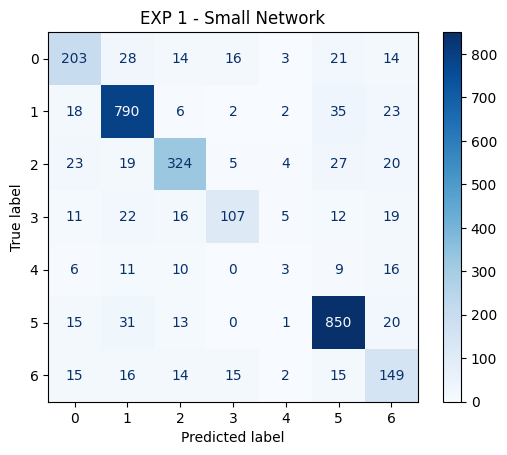

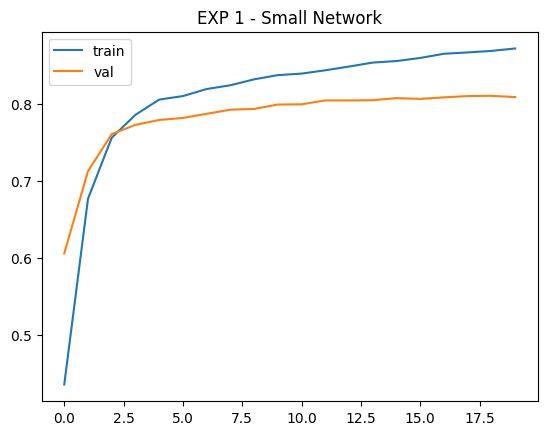

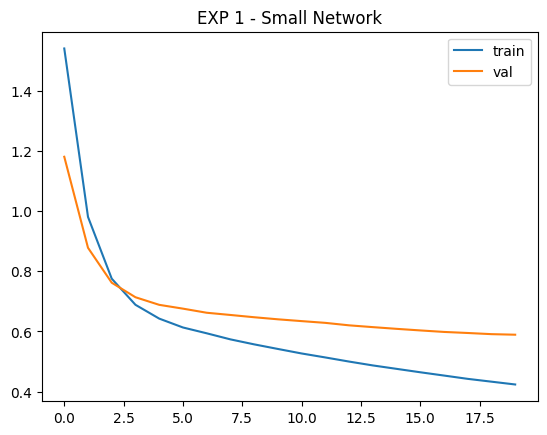

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step


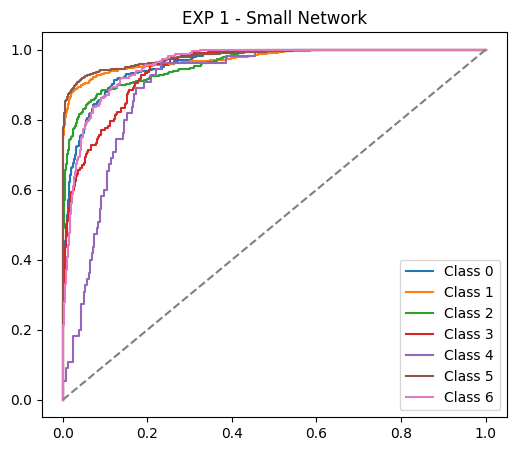

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# exp1 - small network
m1 = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dense(num_classes, activation="softmax")
])
m1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
h1 = m1.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m1.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 1 - Small Network",
    acc, prec, rec, f1,
    h1.history["loss"][-1],
    h1.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 1 - Small Network")
plt.show()

# Accuracy Curve
plt.plot(h1.history["accuracy"])
plt.plot(h1.history["val_accuracy"])
plt.title("EXP 1 - Small Network")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h1.history["loss"])
plt.plot(h1.history["val_loss"])
plt.title("EXP 1 - Small Network")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m1.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 1 - Small Network")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6051 - loss: 1.1358 - val_accuracy: 0.7397 - val_loss: 0.7783
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7849 - loss: 0.6874 - val_accuracy: 0.7803 - val_loss: 0.6715
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8140 - loss: 0.5915 - val_accuracy: 0.7960 - val_loss: 0.6307
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8380 - loss: 0.5287 - val_accuracy: 0.7963 - val_loss: 0.6133
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8517 - loss: 0.4847 - val_accuracy: 0.8027 - val_loss: 0.5927
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8591 - loss: 0.4506 - val_accuracy: 0.8040 - val_loss: 0.5885
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 0.4218 - val_accuracy: 0.8117 - val_loss: 0.5849
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8740 - loss: 0.3951 - val_accuracy: 0.

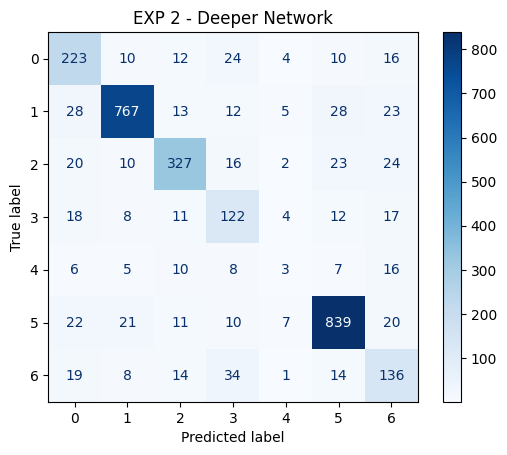

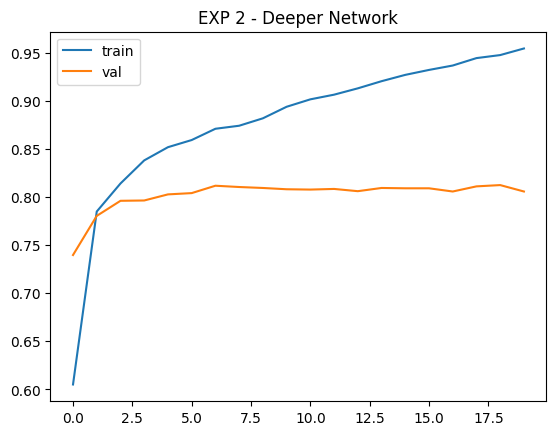

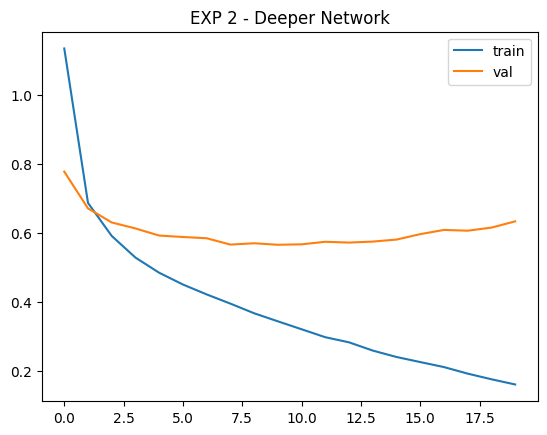

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step


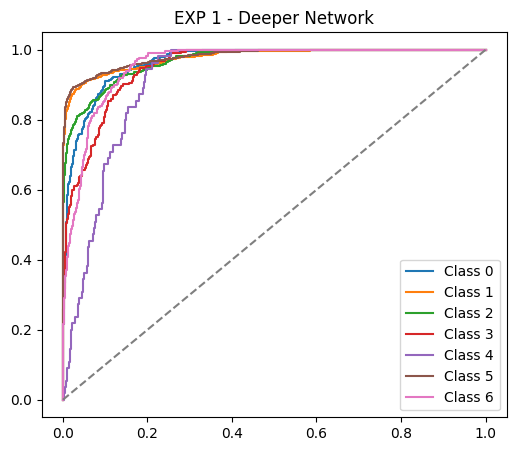

In [ ]:
m2 = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])
m2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
h2 = m2.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m2.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 2 - Deeper Network",
    acc, prec, rec, f1,
    h2.history["loss"][-1],
    h2.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 2 - Deeper Network")
plt.show()

# Accuracy Curve
plt.plot(h2.history["accuracy"])
plt.plot(h2.history["val_accuracy"])
plt.title("EXP 2 - Deeper Network")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h2.history["loss"])
plt.plot(h2.history["val_loss"])
plt.title("EXP 2 - Deeper Network")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m2.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 1 - Deeper Network")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5366 - loss: 1.3128 - val_accuracy: 0.6700 - val_loss: 0.9689
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7020 - loss: 0.8844 - val_accuracy: 0.7383 - val_loss: 0.7846
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7394 - loss: 0.7629 - val_accuracy: 0.7637 - val_loss: 0.7164
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7711 - loss: 0.6988 - val_accuracy: 0.7737 - val_loss: 0.6814
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7820 - loss: 0.6615 - val_accuracy: 0.7810 - val_loss: 0.6577
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.6277 - val_accuracy: 0.7830 - val_loss: 0.6426
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8046 - loss: 0.5900 - val_accuracy: 0.7933 - val_loss: 0.6283
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8126 - loss: 0.5805 - val_accuracy: 0.

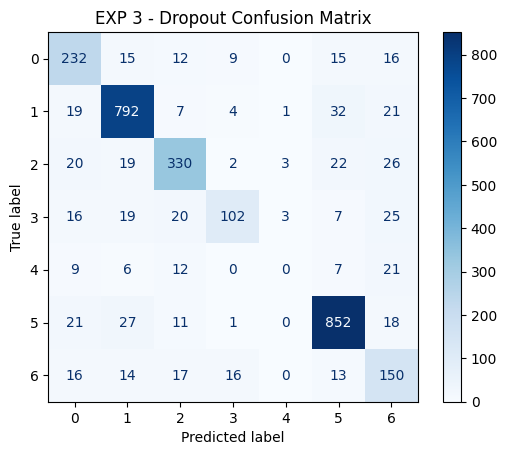

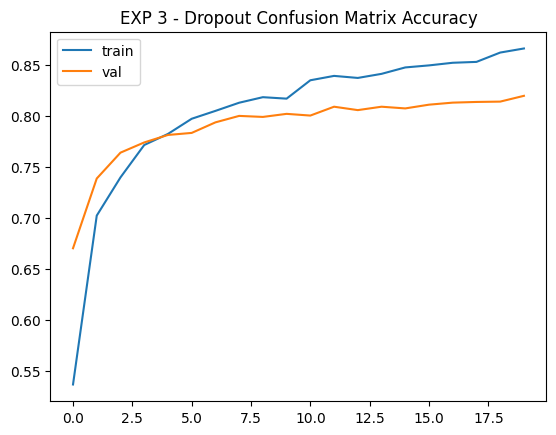

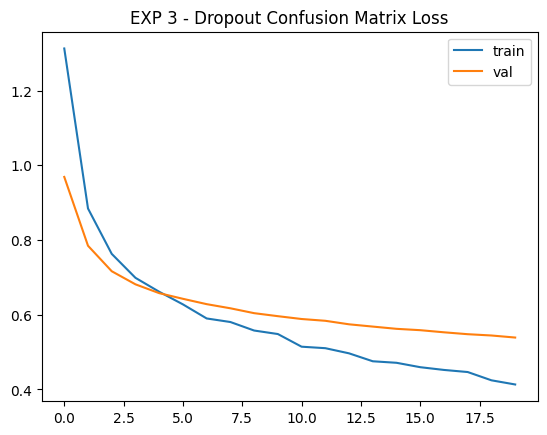

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step


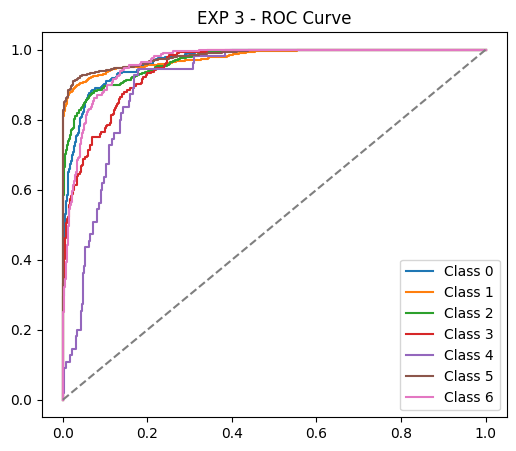

In [ ]:
# exp 3 - dropout
# 1. Build model
m3 = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

# 2. Compile
m3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 3. Train
h3 = m3.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m3.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 3 - Dropout (0.3)",
    acc, prec, rec, f1,
    h3.history["loss"][-1],
    h3.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 3 - Dropout Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h3.history["accuracy"])
plt.plot(h3.history["val_accuracy"])
plt.title("EXP 3 - Dropout Confusion Matrix Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h3.history["loss"])
plt.plot(h3.history["val_loss"])
plt.title("EXP 3 - Dropout Confusion Matrix Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m3.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 3 - ROC Curve")
plt.legend()
plt.show()


Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5440 - loss: 1.3137 - val_accuracy: 0.6760 - val_loss: 0.9998
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7483 - loss: 0.7609 - val_accuracy: 0.7410 - val_loss: 0.7742
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7794 - loss: 0.6690 - val_accuracy: 0.7647 - val_loss: 0.7097
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7951 - loss: 0.6349 - val_accuracy: 0.7737 - val_loss: 0.6925
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8111 - loss: 0.5911 - val_accuracy: 0.7807 - val_loss: 0.6825
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8203 - loss: 0.5515 - val_accuracy: 0.7850 - val_loss: 0.6617
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8331 - loss: 0.5105 - val_accuracy: 0.7863 - val_loss: 0.6608
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8471 - loss: 0.4818 - val_accuracy: 0.

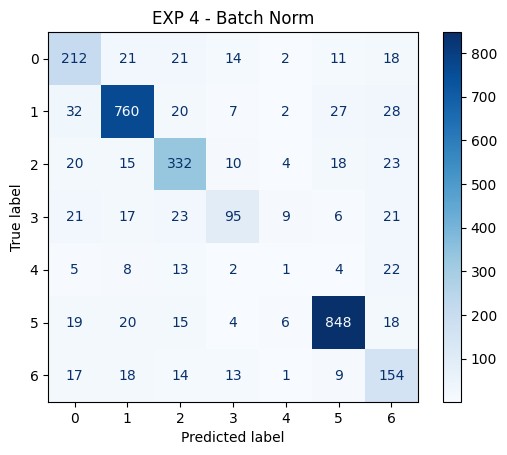

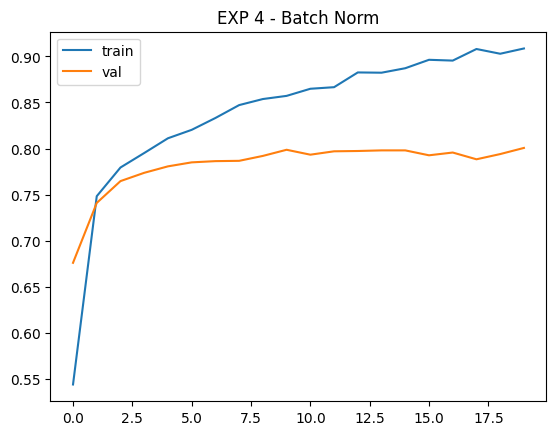

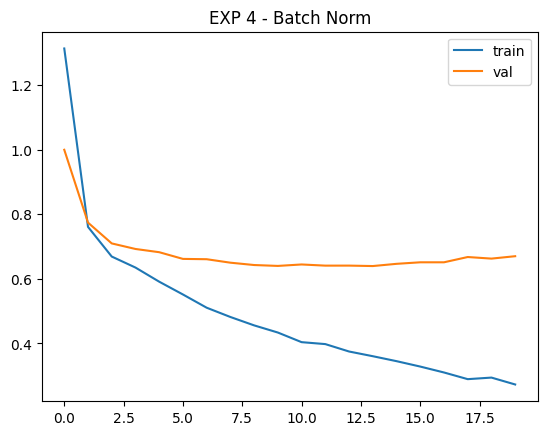

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step


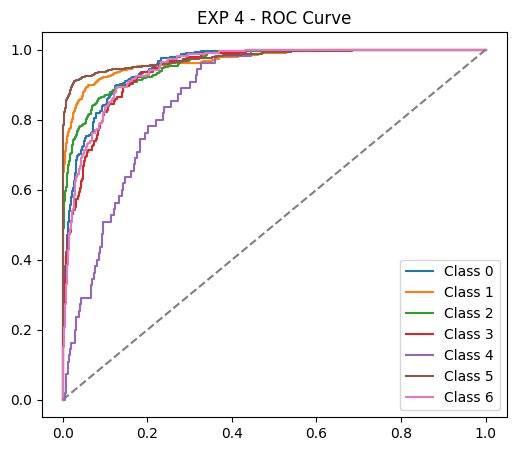

In [ ]:
# exp 4 - batch norm
m4 = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(num_classes, activation="softmax")
])
m4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
h4 = m4.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m4.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 4 - Batch Norm",
    acc, prec, rec, f1,
    h4.history["loss"][-1],
    h4.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 4 - Batch Norm")
plt.show()

# Accuracy Curve
plt.plot(h4.history["accuracy"])
plt.plot(h4.history["val_accuracy"])
plt.title("EXP 4 - Batch Norm")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h4.history["loss"])
plt.plot(h4.history["val_loss"])
plt.title("EXP 4 - Batch Norm")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m4.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 4 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4200 - loss: 1.5991 - val_accuracy: 0.5870 - val_loss: 1.2425
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6511 - loss: 1.0656 - val_accuracy: 0.6887 - val_loss: 0.9548
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7211 - loss: 0.8538 - val_accuracy: 0.7257 - val_loss: 0.8206
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7583 - loss: 0.7479 - val_accuracy: 0.7550 - val_loss: 0.7525
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.6875 - val_accuracy: 0.7720 - val_loss: 0.7163
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.6505 - val_accuracy: 0.7777 - val_loss: 0.6923
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8066 - loss: 0.6251 - val_accuracy: 0.7810 - val_loss: 0.6774
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8171 - loss: 0.6038 - val_accuracy: 0.

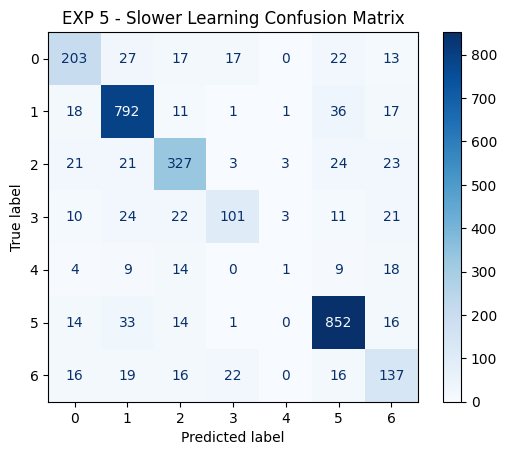

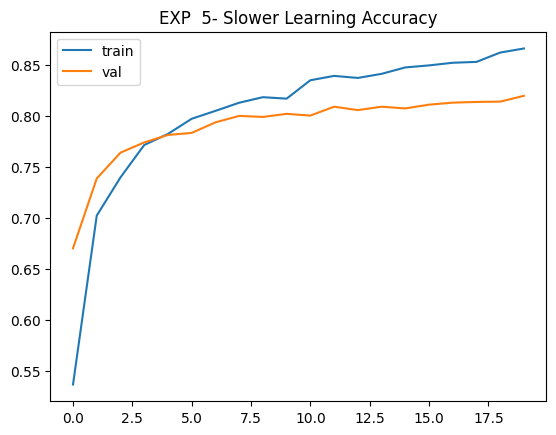

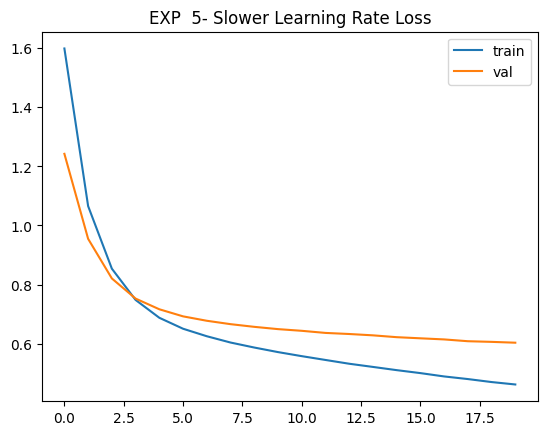

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step


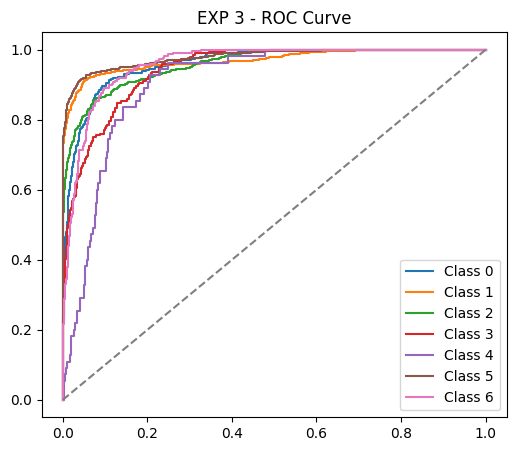

In [ ]:
# exp 5 - 128 dense, learning rate = 0.0005
m5 = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(num_classes, activation="softmax")
])

m5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h5 = m5.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m5.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP  5- Slower Learning Rate",
    acc, prec, rec, f1,
    h5.history["loss"][-1],
    h5.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 5 - Slower Learning Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h3.history["accuracy"])
plt.plot(h3.history["val_accuracy"])
plt.title("EXP  5- Slower Learning Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h5.history["loss"])
plt.plot(h5.history["val_loss"])
plt.title("EXP  5- Slower Learning Rate Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m5.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 3 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7343 - loss: 0.7920 - val_accuracy: 0.7797 - val_loss: 0.6512
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8129 - loss: 0.5486 - val_accuracy: 0.7900 - val_loss: 0.6317
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8380 - loss: 0.4697 - val_accuracy: 0.8050 - val_loss: 0.5906
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8637 - loss: 0.3940 - val_accuracy: 0.8083 - val_loss: 0.5715
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8880 - loss: 0.3295 - val_accuracy: 0.8127 - val_loss: 0.5825
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9020 - loss: 0.2774 - val_accuracy: 0.8157 - val_loss: 0.6058
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9209 - loss: 0.2396 - val_accuracy: 0.8103 - val_loss: 0.6480
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9351 - loss: 0.1867 - val_accuracy: 0.

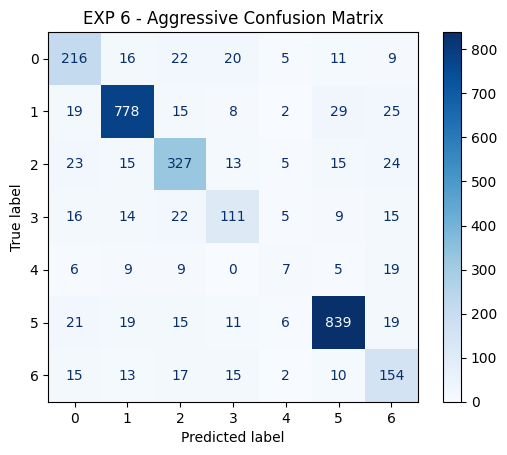

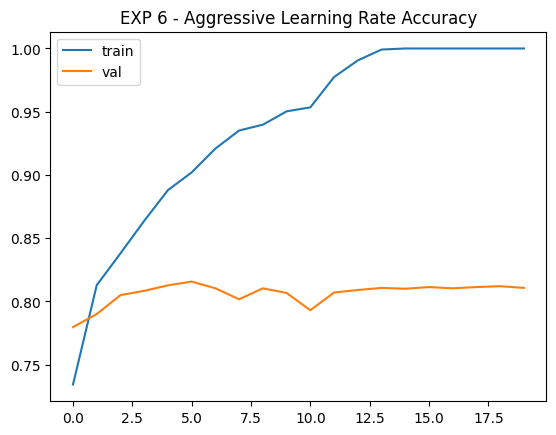

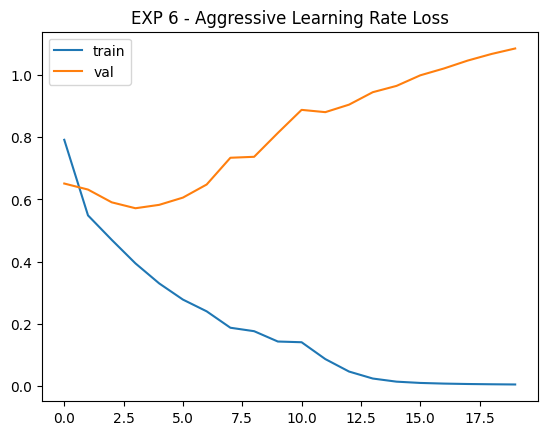

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step


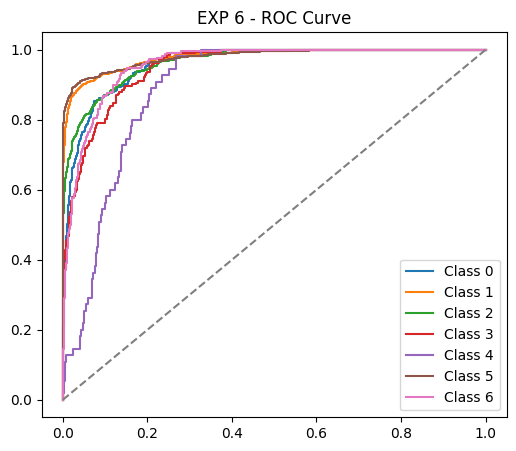

In [ ]:
# exp 6 — Learning Rate = 0.01 (Aggressive Learning)
m6 = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(num_classes, activation="softmax")
])

m6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h6 = m6.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m6.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 6 - Aggressive Learning Rate",
    acc, prec, rec, f1,
    h6.history["loss"][-1],
    h6.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 6 - Aggressive Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h6.history["accuracy"])
plt.plot(h6.history["val_accuracy"])
plt.title("EXP 6 - Aggressive Learning Rate Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h6.history["loss"])
plt.plot(h6.history["val_loss"])
plt.title("EXP 6 - Aggressive Learning Rate Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m6.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 6 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5194 - loss: 1.3328 - val_accuracy: 0.6987 - val_loss: 0.8726
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6837 - loss: 0.9254 - val_accuracy: 0.7493 - val_loss: 0.7283
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7203 - loss: 0.8065 - val_accuracy: 0.7747 - val_loss: 0.6579
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7417 - loss: 0.7498 - val_accuracy: 0.7867 - val_loss: 0.6226
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7711 - loss: 0.6888 - val_accuracy: 0.7970 - val_loss: 0.6006
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7800 - loss: 0.6554 - val_accuracy: 0.8070 - val_loss: 0.5832
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.6113 - val_accuracy: 0.8113 - val_loss: 0.5597
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7903 - loss: 0.6037 - val_accuracy: 0.

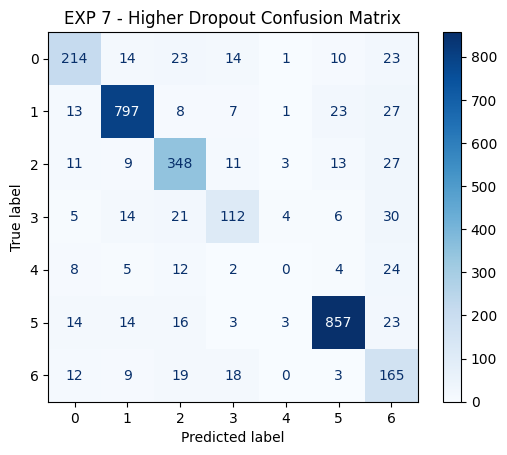

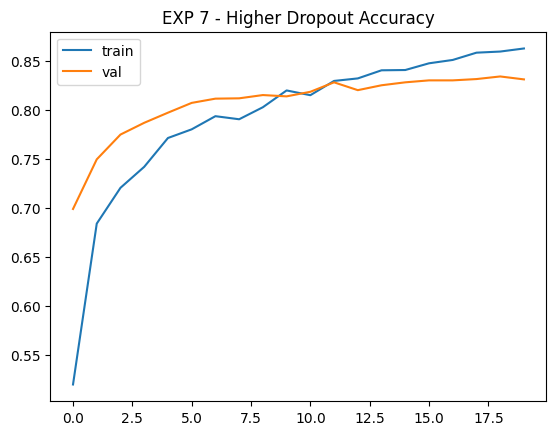

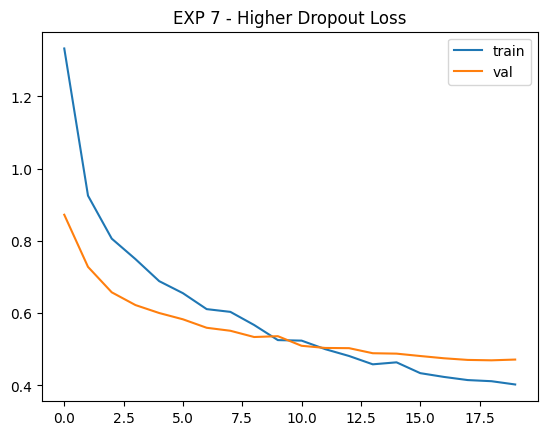

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step


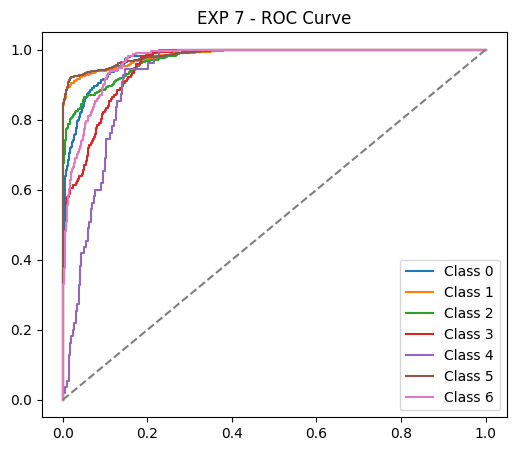

In [ ]:
# exp 7 — Dropout 0.5 (Strong Regularization)
m7 = Sequential([
    Dense(256, activation="relu", input_shape=(input_dim,)),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

m7.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h7 = m7.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m7.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results
dl_results.append([
    "EXP 7 - Dropout (0.5)",
    acc, prec, rec, f1,
    h7.history["loss"][-1],
    h7.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 7 - Higher Dropout Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h7.history["accuracy"])
plt.plot(h7.history["val_accuracy"])
plt.title("EXP 7 - Higher Dropout Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h7.history["loss"])
plt.plot(h7.history["val_loss"])
plt.title("EXP 7 - Higher Dropout Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m7.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 7 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6751 - loss: 0.9573 - val_accuracy: 0.7787 - val_loss: 0.6804
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8134 - loss: 0.5806 - val_accuracy: 0.7973 - val_loss: 0.6071
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8451 - loss: 0.4697 - val_accuracy: 0.8043 - val_loss: 0.5796
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8637 - loss: 0.4043 - val_accuracy: 0.8047 - val_loss: 0.5909
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8811 - loss: 0.3533 - val_accuracy: 0.8177 - val_loss: 0.5471
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9000 - loss: 0.3063 - val_accuracy: 0.8083 - val_loss: 0.5617
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9080 - loss: 0.2788 - val_accuracy: 0.8230 - val_loss: 0.5594
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9194 - loss: 0.2350 - val_accuracy: 0.

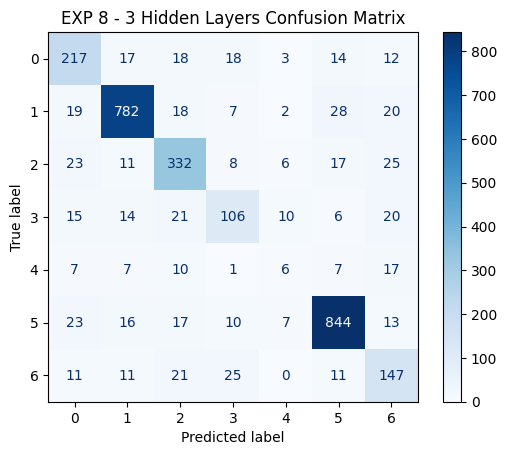

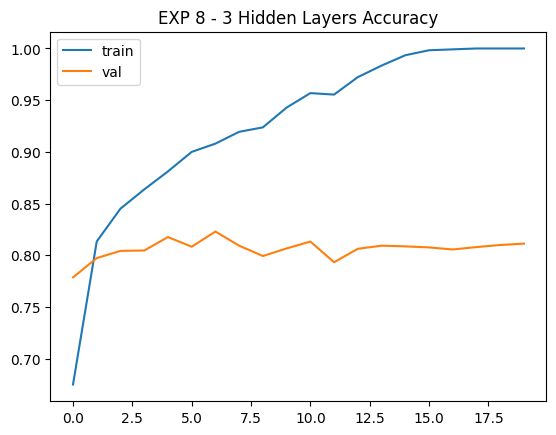

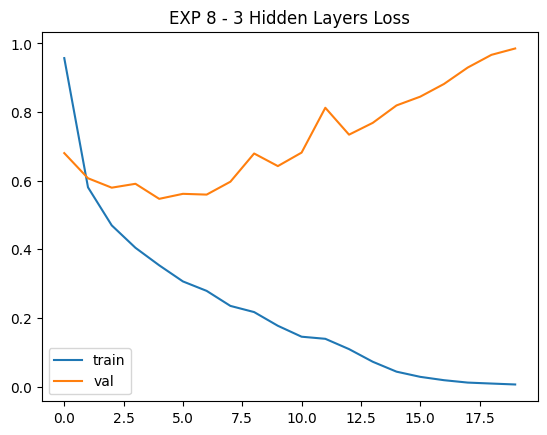

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step


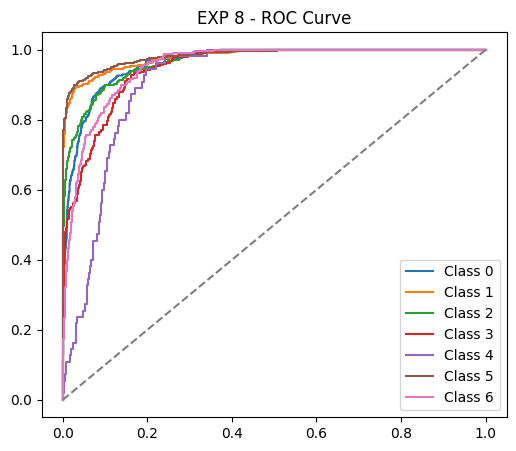

In [ ]:
# exp 8 — 3 Hidden Layers (Increased Depth)
m8 = Sequential([
    Dense(256, activation="relu", input_shape=(input_dim,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

m8.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h8 = m8.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m8.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 8 - Increase Depth (3 Hidden layer)",
    acc, prec, rec, f1,
    h8.history["loss"][-1],
    h8.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 8 - 3 Hidden Layers Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h8.history["accuracy"])
plt.plot(h8.history["val_accuracy"])
plt.title("EXP 8 - 3 Hidden Layers Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h8.history["loss"])
plt.plot(h8.history["val_loss"])
plt.title("EXP 8 - 3 Hidden Layers Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m8.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 8 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7109 - loss: 0.8513 - val_accuracy: 0.7730 - val_loss: 0.6667
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8206 - loss: 0.5569 - val_accuracy: 0.7983 - val_loss: 0.6033
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8523 - loss: 0.4616 - val_accuracy: 0.8087 - val_loss: 0.5749
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8654 - loss: 0.3982 - val_accuracy: 0.8110 - val_loss: 0.5668
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.3341 - val_accuracy: 0.8137 - val_loss: 0.5530
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9080 - loss: 0.2878 - val_accuracy: 0.8110 - val_loss: 0.5584
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9214 - loss: 0.2369 - val_accuracy: 0.8123 - val_loss: 0.5698
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9300 - loss: 0.2141 - val_accuracy: 0.

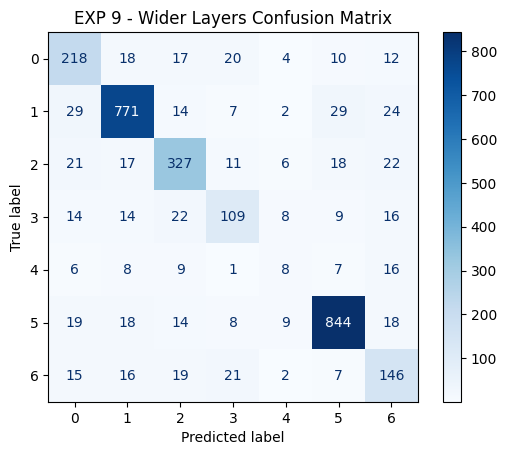

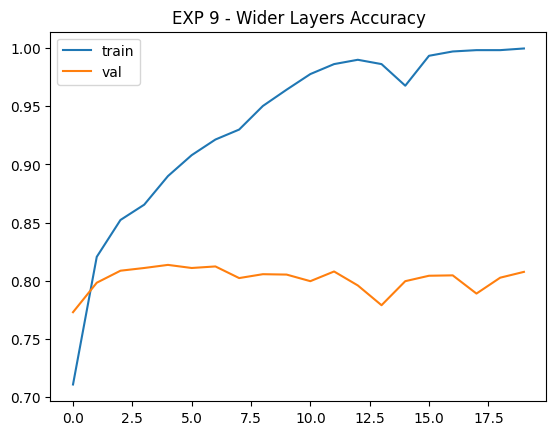

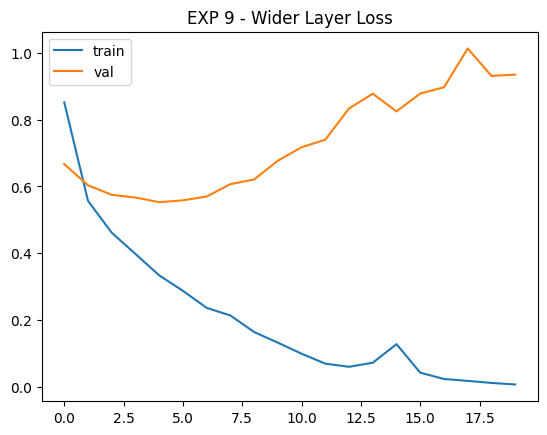

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step


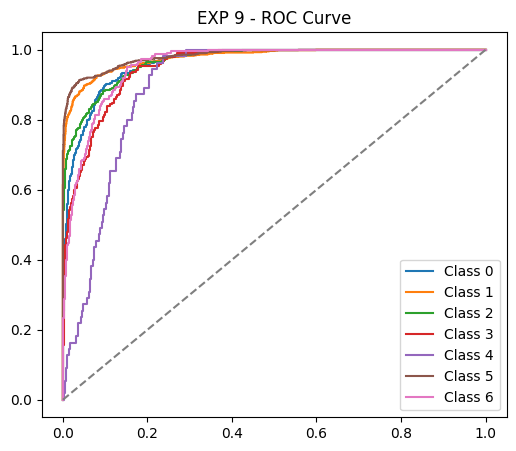

In [ ]:
# exp 9 — Wider Layers (Increased Capacity)
m9 = Sequential([
    Dense(512, activation="relu", input_shape=(input_dim,)),
    Dense(256, activation="relu"),
    Dense(num_classes, activation="softmax")
])

m9.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h9 = m9.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m9.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 9 - Wider Layer",
    acc, prec, rec, f1,
    h9.history["loss"][-1],
    h9.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 9 - Wider Layers Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h9.history["accuracy"])
plt.plot(h9.history["val_accuracy"])
plt.title("EXP 9 - Wider Layers Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h9.history["loss"])
plt.plot(h9.history["val_loss"])
plt.title("EXP 9 - Wider Layer Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m9.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 9 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6751 - loss: 0.9532 - val_accuracy: 0.7640 - val_loss: 0.7002
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8154 - loss: 0.5882 - val_accuracy: 0.7947 - val_loss: 0.6165
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8489 - loss: 0.4895 - val_accuracy: 0.8123 - val_loss: 0.5715
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.4200 - val_accuracy: 0.8120 - val_loss: 0.5658
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8769 - loss: 0.3723 - val_accuracy: 0.8183 - val_loss: 0.5695
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8894 - loss: 0.3269 - val_accuracy: 0.8160 - val_loss: 0.5653
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9009 - loss: 0.2990 - val_accuracy: 0.8110 - val_loss: 0.5778
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9031 - loss: 0.2746 - val_accuracy: 0.

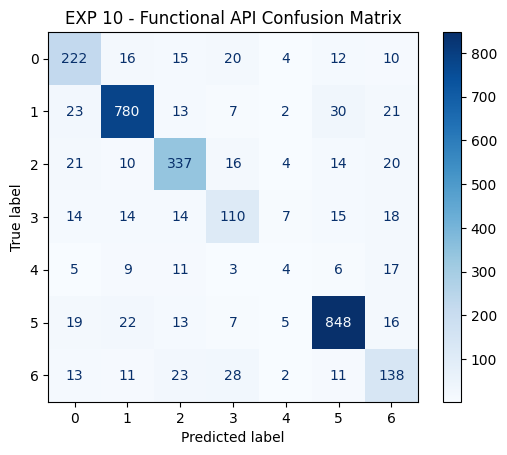

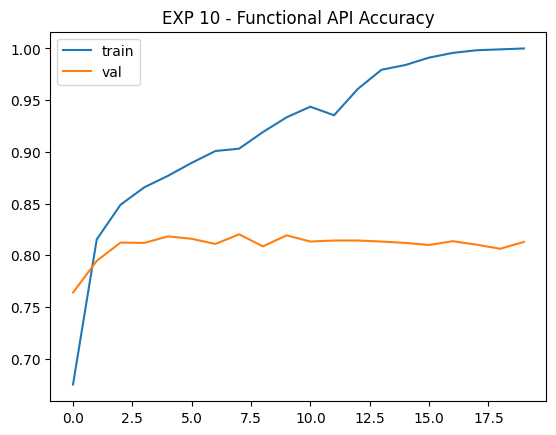

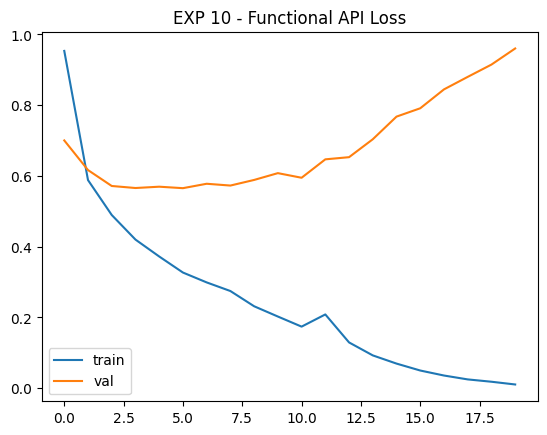

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step


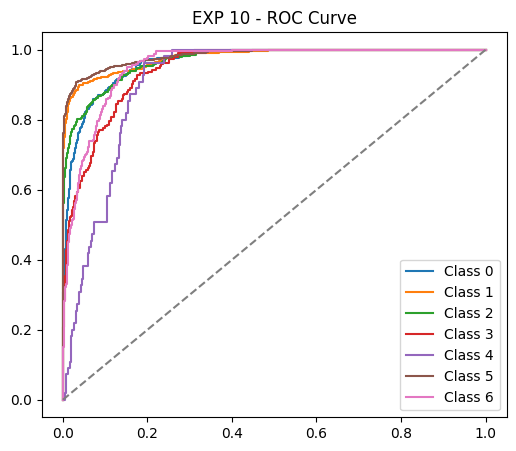

In [ ]:
# exp 10 - Functional API Model (Same Structure, Better Flexibility)
inputs = Input(shape=(input_dim,))

x = Dense(256, activation="relu")(inputs)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)

outputs = Dense(num_classes, activation="softmax")(x)

m10 = Model(inputs, outputs)

m10.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h10 = m10.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m10.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 10 - Functional API",
    acc, prec, rec, f1,
    h10.history["loss"][-1],
    h10.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 10 - Functional API Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h10.history["accuracy"])
plt.plot(h10.history["val_accuracy"])
plt.title("EXP 10 - Functional API Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h10.history["loss"])
plt.plot(h10.history["val_loss"])
plt.title("EXP 10 - Functional API Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m10.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 10 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7234 - loss: 0.8105 - val_accuracy: 0.7737 - val_loss: 0.6737
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8243 - loss: 0.5477 - val_accuracy: 0.8033 - val_loss: 0.5876
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8531 - loss: 0.4472 - val_accuracy: 0.7977 - val_loss: 0.5935
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.3863 - val_accuracy: 0.8183 - val_loss: 0.5575
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8909 - loss: 0.3306 - val_accuracy: 0.8067 - val_loss: 0.5558
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9117 - loss: 0.2762 - val_accuracy: 0.8057 - val_loss: 0.5643
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9171 - loss: 0.2456 - val_accuracy: 0.8050 - val_loss: 0.6176
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9331 - loss: 0.2044 - val_accuracy: 0.

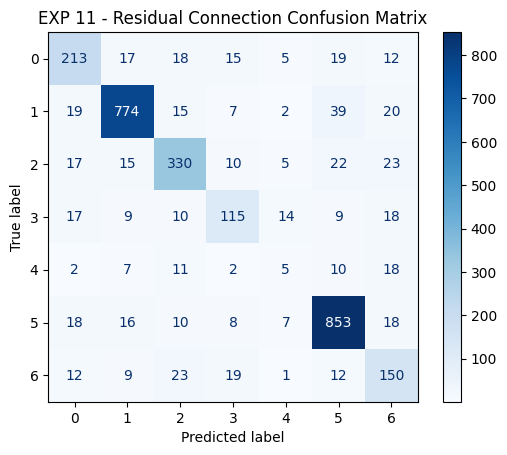

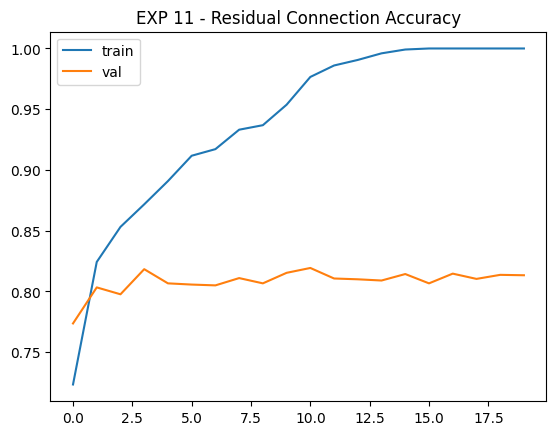

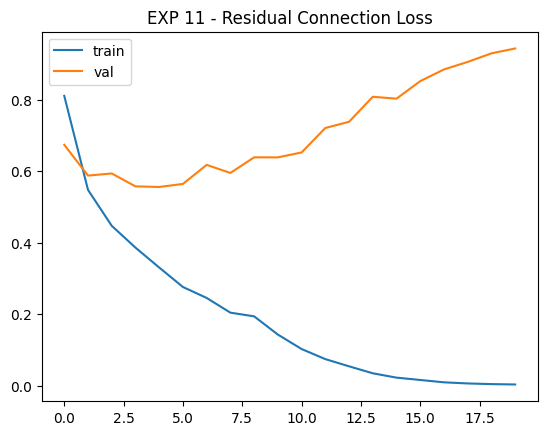

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


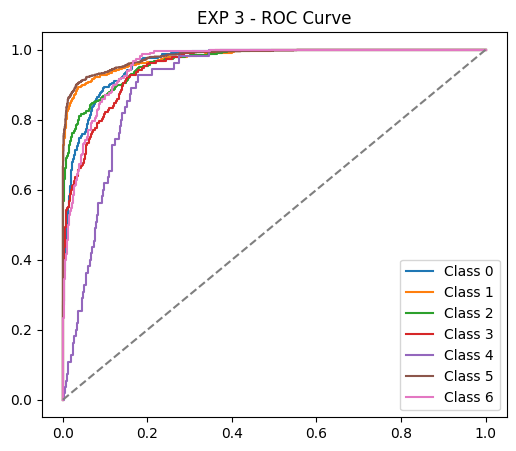

In [ ]:
# exp 11 - Residual Connection
inputs = Input(shape=(input_dim,))

x = Dense(256, activation="relu")(inputs)
x = Dense(256, activation="relu")(x)

skip = Dense(256, activation="linear")(inputs)

x = tf.keras.layers.Add()([x, skip])
x = Dense(128, activation="relu")(x)

outputs = Dense(num_classes, activation="softmax")(x)

m11 = Model(inputs, outputs)

m11.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h11 = m11.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m11.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 11 - Residual Connection",
    acc, prec, rec, f1,
    h3.history["loss"][-1],
    h3.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 11 - Residual Connection Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h11.history["accuracy"])
plt.plot(h11.history["val_accuracy"])
plt.title("EXP 11 - Residual Connection Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h11.history["loss"])
plt.plot(h11.history["val_loss"])
plt.title("EXP 11 - Residual Connection Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m11.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 3 - ROC Curve")
plt.legend()
plt.show()

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5409 - loss: 1.3459 - val_accuracy: 0.7200 - val_loss: 1.0938
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7114 - loss: 0.8750 - val_accuracy: 0.7707 - val_loss: 0.7714
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7411 - loss: 0.7476 - val_accuracy: 0.7903 - val_loss: 0.6701
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7803 - loss: 0.6815 - val_accuracy: 0.7993 - val_loss: 0.6237
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7820 - loss: 0.6514 - val_accuracy: 0.7980 - val_loss: 0.6032
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7929 - loss: 0.5985 - val_accuracy: 0.8047 - val_loss: 0.5786
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8043 - loss: 0.5901 - val_accuracy: 0.8117 - val_loss: 0.5618
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8051 - loss: 0.5698 - val_accuracy: 0.

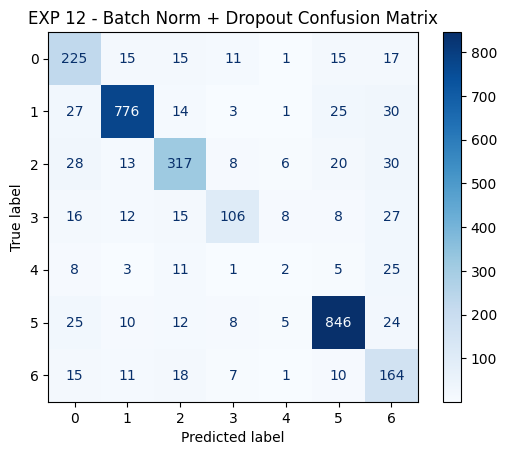

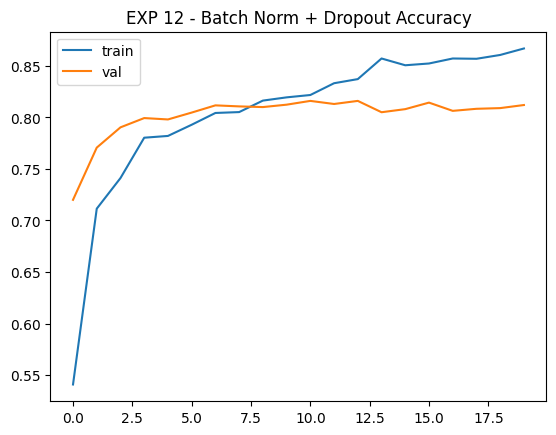

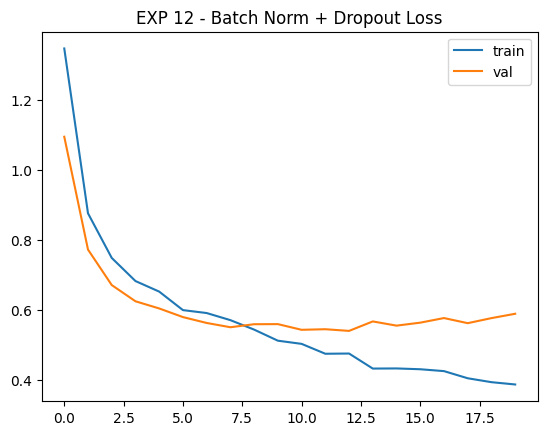

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step


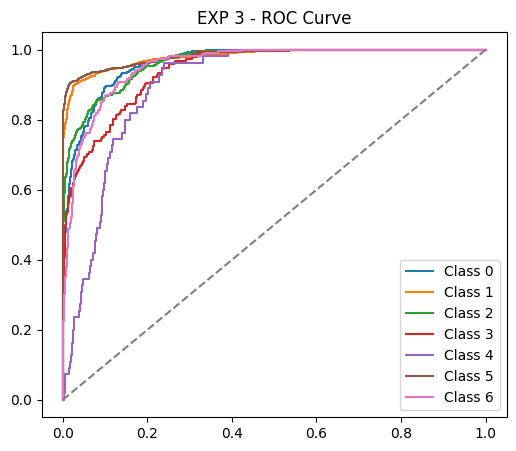

In [ ]:
# exp 12 - BatchNorm + Dropout Combo (Best Regularized Model)
m12 = Sequential([
    Dense(256, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),

    Dense(num_classes, activation="softmax")
])

m12.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h12 = m12.fit(train_ds, validation_data=test_ds, epochs=20)

# 4. Predict
preds = np.argmax(m12.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 12 - Batch Norm + Dropout (0.3)",
    acc, prec, rec, f1,
    h12.history["loss"][-1],
    h12.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 12 - Batch Norm + Dropout Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h12.history["accuracy"])
plt.plot(h12.history["val_accuracy"])
plt.title("EXP 12 - Batch Norm + Dropout Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h12.history["loss"])
plt.plot(h12.history["val_loss"])
plt.title("EXP 12 - Batch Norm + Dropout Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m12.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 3 - ROC Curve")
plt.legend()
plt.show()

8. Deep Learning Functional API

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5937 - loss: 1.1527 - val_accuracy: 0.7130 - val_loss: 1.0226
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - loss: 0.7253 - val_accuracy: 0.7760 - val_loss: 0.7185
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7826 - loss: 0.6391 - val_accuracy: 0.7850 - val_loss: 0.6318
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.5839 - val_accuracy: 0.7880 - val_loss: 0.6055
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8149 - loss: 0.5327 - val_accuracy: 0.7910 - val_loss: 0.5922
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8254 - loss: 0.4832 - val_accuracy: 0.7907 - val_loss: 0.5921
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.4664 - val_accuracy: 0.8037 - val_loss: 0.5866
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8440 - loss: 0.4359 - val_accuracy: 0.

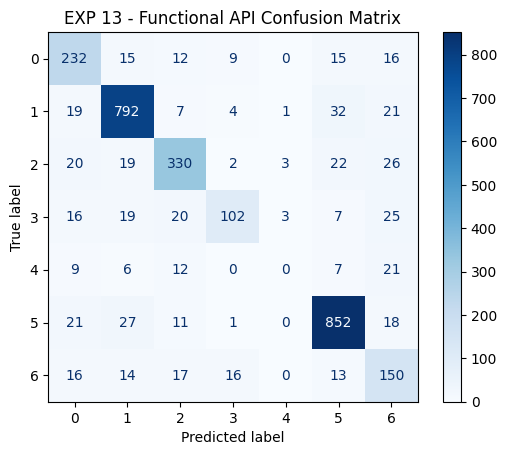

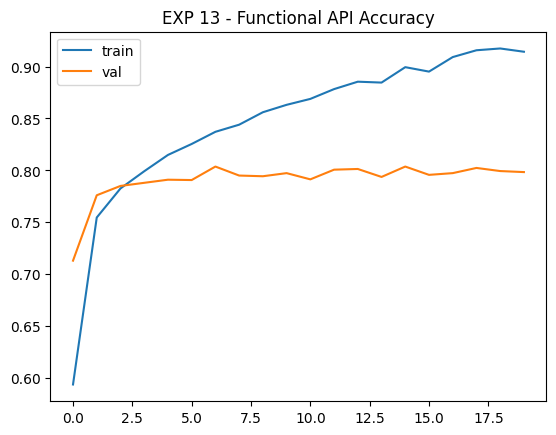

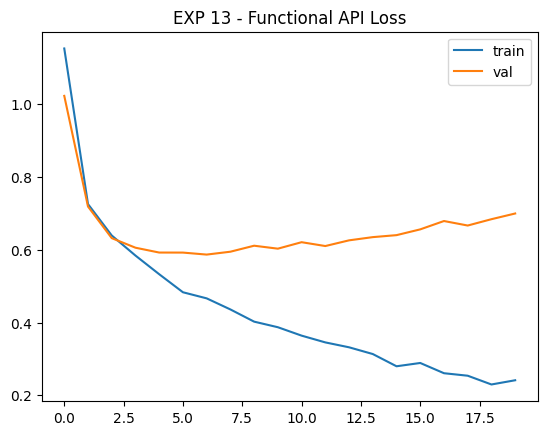

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


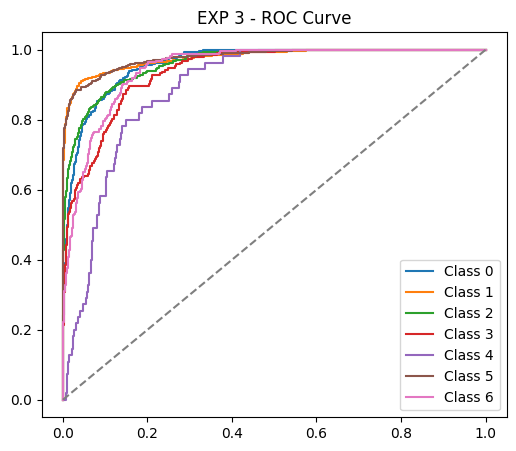

In [ ]:
inputs = Input(shape=(input_dim,))

x = Dense(256, activation="relu")(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)

x = Dense(64, activation="relu")(x)

outputs = Dense(num_classes, activation="softmax")(x)

m13 = Model(inputs, outputs)

m13.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h13 = m13.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    verbose=1
)

# 4. Predict
preds = np.argmax(m3.predict(X_test_dl), axis=1)

# 5. Evaluate
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="weighted")
rec = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# 6. Store results (CRITICAL)
dl_results.append([
    "EXP 13 - Functional API",
    acc, prec, rec, f1,
    h13.history["loss"][-1],
    h13.history["val_loss"][-1]
])

#7. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("EXP 13 - Functional API Confusion Matrix")
plt.show()

# Accuracy Curve
plt.plot(h13.history["accuracy"])
plt.plot(h13.history["val_accuracy"])
plt.title("EXP 13 - Functional API Accuracy")
plt.legend(["train","val"])
plt.show()

# Loss Curve
plt.plot(h13.history["loss"])
plt.plot(h13.history["val_loss"])
plt.title("EXP 13 - Functional API Loss")
plt.legend(["train","val"])
plt.show()

#roc curve
# probabilities
probs = m13.predict(X_test_dl)

# binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(6,5))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"--")
plt.title("EXP 3 - ROC Curve")
plt.legend()
plt.show()

9. Evaluating Deep Learning Models

DL Results Table

In [ ]:
dl_df = pd.DataFrame(
    dl_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "Train Loss", "Val Loss"]
)

dl_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,Train Loss,Val Loss
6,EXP 7 - Dropout (0.5),0.831000,0.828413,0.831000,0.827908,0.402746,0.471719
12,EXP 13 - Functional API,0.819333,0.810317,0.819333,0.812762,0.241440,0.699475
2,EXP 3 - Dropout (0.3),0.819333,0.810317,0.819333,0.812762,0.413245,0.538891
10,EXP 11 - Residual Connection,0.813333,0.811494,0.813333,0.811894,0.413245,0.538891
11,EXP 12 - Batch Norm + Dropout (0.3),0.812000,0.815781,0.812000,0.811042,0.386045,0.588039
9,EXP 10 - Functional API,0.813000,0.808948,0.813000,0.810641,0.010546,0.960106
7,EXP 8 - Increase Depth (3 Hidden layer),0.811333,0.809506,0.811333,0.809927,0.005940,0.985363
5,EXP 6 - Aggressive Learning Rate,0.810667,0.809807,0.810667,0.809578,0.003960,1.086123
8,EXP 9 - Wider Layer,0.807667,0.807285,0.807667,0.807048,0.007820,0.934301
1,EXP 2 - Deeper Network,0.805667,0.807970,0.805667,0.805707,0.160354,0.633902


## Final Comparison

In [ ]:
final = pd.concat([ml_df, dl_df])
final.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,Train Loss,Val Loss
3,RF Deep,0.880000,0.890904,0.880000,0.880157,NaN,NaN
4,XGB Default,0.879000,0.879342,0.879000,0.878734,NaN,NaN
5,XGB trial,0.880000,0.876171,0.880000,0.877466,NaN,NaN
6,XGB Tuned LR,0.877000,0.876518,0.877000,0.876076,NaN,NaN
6,EXP 7 - Dropout (0.5),0.831000,0.828413,0.831000,0.827908,0.402746,0.471719
2,RF Shallow,0.830333,0.820759,0.830333,0.820183,NaN,NaN
12,EXP 13 - Functional API,0.819333,0.810317,0.819333,0.812762,0.241440,0.699475
2,EXP 3 - Dropout (0.3),0.819333,0.810317,0.819333,0.812762,0.413245,0.538891
10,EXP 11 - Residual Connection,0.813333,0.811494,0.813333,0.811894,0.413245,0.538891
11,EXP 12 - Batch Norm + Dropout (0.3),0.812000,0.815781,0.812000,0.811042,0.386045,0.588039
